In [2]:
import os
import pandas as pd
import numpy as np

In [3]:
from scipy.optimize import curve_fit, fsolve
from scipy.integrate import quad
import matplotlib.pyplot as plt
from labmate.acquisition_notebook import AcquisitionAnalysisManager

In [4]:
from utils.plot_style import set_plot_style 
set_plot_style()

In [6]:
wavelength = 390e-9  # 390 nm in meters

In [7]:
# Some Jupyter instance will not be launched in the root folder of the repository, so we need to change the working directory to access the data and utils modules. We check the current working directory and move up one level if needed.
# RUN ONLY ONCE! (if necessary)
print(os.getcwd())
os.chdir('..')
print(os.getcwd())

C:\Users\wilan\PycharmProjects\PANDAManager\plot
C:\Users\wilan\PycharmProjects\PANDAManager


## QPM Temperature

### Load data

In [9]:
path_folder_data = r"./data/data_temp_SHG/SHG_temp_input_power_scan/2026-06-15_ppktp_svenska_20_luke_001/"
print(path_folder_data)

# Run names
name_exp = "SHG_temp_input_power_scan_ppktp_svenska_20_luke"
# List all files in the folder
folder_data_files = os.listdir(path_folder_data + '/' + name_exp)
print(folder_data_files)

./data/data_temp_SHG/SHG_temp_input_power_scan/2026-06-15_ppktp_svenska_20_luke_001/
['2026_06_15__16_18_19__SHG_temp_input_power_scan_ppktp_svenska_20_luke.h5']


In [10]:
# Choose file
name = "2026_06_15__16_18_19__SHG_temp_input_power_scan_ppktp_svenska_20_luke.h5"

full_path = os.path.join(path_folder_data, name_exp, name)
print(full_path)

# Init acquisition analysis manager
aqm = AcquisitionAnalysisManager(full_path)
aqm.analysis_cell(filename=full_path)
print(aqm.data)

./data/data_temp_SHG/SHG_temp_input_power_scan/2026-06-15_ppktp_svenska_20_luke_001/SHG_temp_input_power_scan_ppktp_svenska_20_luke\2026_06_15__16_18_19__SHG_temp_input_power_scan_ppktp_svenska_20_luke.h5


INFO:2026_06_15__16_18_19__SHG_temp_input_power_scan_ppktp_svenska_20_luke


AnalysisData (rw) (not saved): 
 {
    "acquisition_cell" (r): {
        "1": "variable of type str"
    },
    "error_in_mW" (r): "5.197e-02 (type : float64)",
    "experiment_name" (r): "variable of type str",
    "info" (r): {
        "acquisition_duration": "6.449e+02 (type : float64)",
        "logs": "variable of type str",
        "prints": "variable of type str"
    },
    "list_SHG_errors" (r): "shape: (26,) (type: ndarray)",
    "list_SHG_powers" (r): "shape: (26,) (type: ndarray)",
    "list_Terrors" (r): "shape: (26,) (type: ndarray)",
    "list_Tmeas" (r): "shape: (26,) (type: ndarray)",
    "pump_power_mW" (r): "1.037e+02 (type : float64)",
    "useful" (r): "variable of type bool_"
}


### Single QPM

In [11]:
list_T = np.array(aqm.data['list_Tmeas'])
list_P = np.array(aqm.data['list_SHG_powers'])
list_Perr = np.array(aqm.data['list_SHG_errors'])
list_Terr = np.array(aqm.data['list_Terrors'])

In [12]:
threshold = 0.005  # adjust based on your noise floor

mask = list_P > threshold

list_P = list_P[mask]
list_T = list_T[mask]
list_Perr = list_Perr[mask]
list_Terr = list_Terr[mask]

In [13]:
# Quasi-phase-matching fit function
def qpm_fit(T, I0, T0, dT, B):
    """
    A_fit = I0 * sinc^2( (T - T0) / dT ) + B
    """
    x = (T - T0) / dT
    return I0 * ((np.sinc(x))**2) + B

In [14]:
# protect against zero/invalid uncertainties
sigma = np.asarray(list_Perr, dtype=float)
sigma[~np.isfinite(sigma) | (sigma <= 0)] = np.nanmedian(sigma[sigma > 0])

p0 = [
    np.max(list_P) - np.min(list_P),
    list_T[np.argmax(list_P)],
    (np.max(list_T) - np.min(list_T)) / 10,
    np.min(list_P)
]

bounds = (
    [0, np.min(list_T), 1e-6, -np.inf],   # lower: I0, T0, dT, B
    [np.inf, np.max(list_T), np.inf, np.inf]
)

popt, pcov = curve_fit(
    qpm_fit,
    list_T,
    list_P,
    p0=p0,
    sigma=sigma,
    absolute_sigma=True,
    bounds=bounds,
    maxfev=10000
)

I0, T0, dT, B = popt
perr = np.sqrt(np.diag(pcov))

print(f"Estimated temperature for maximum SHG power: {T0:.3f} ± {perr[1]:.3f} °C")
print(f"I0 = {I0:.4g} ± {perr[0]:.4g}")
print(f"dT = {dT:.4g} ± {perr[2]:.4g}")
print(f"B  = {B:.4g} ± {perr[3]:.4g}")

Tfit = np.linspace(np.min(list_T), np.max(list_T), 1000)
Pfit = qpm_fit(Tfit, *popt)


Estimated temperature for maximum SHG power: 43.382 ± 0.001 °C
I0 = 5.92 ± 0.008419
dT = 0.6076 ± 0.0007956
B  = 0.311 ± 0.001203


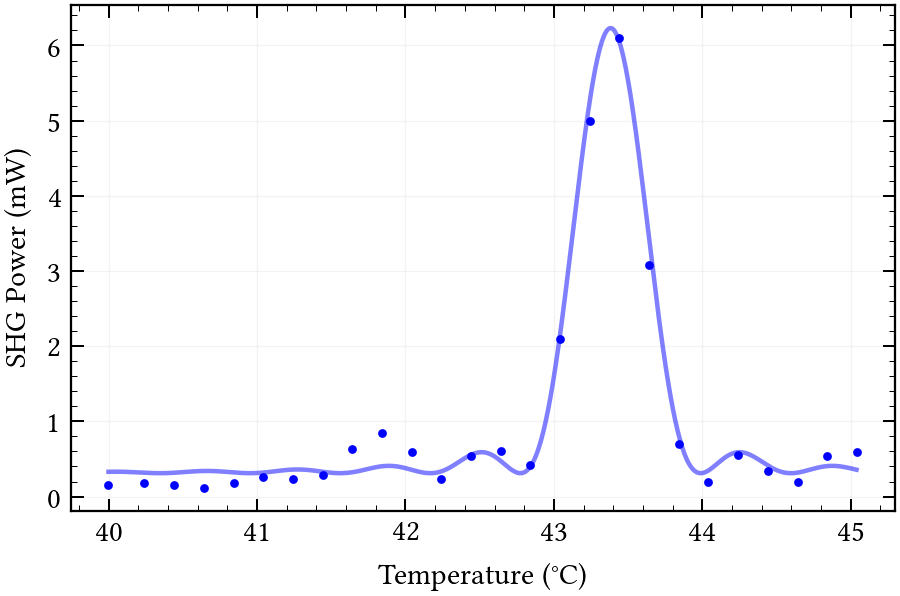

In [21]:
plt.figure()
plt.errorbar(list_T, list_P , xerr=list_Terr, yerr=list_Perr, fmt='.', label='data', color="b")
plt.plot(Tfit, qpm_fit(Tfit, *popt), 'b-', label='fit', alpha=0.5)
plt.xlabel('Temperature (°C)')
plt.ylabel('SHG Power (mW)')
# plt.title('SHG Power vs Temperature')
plt.grid()
plt.show()

### QPM vs $P_{in}$

In [7]:
# QPM vs Input power scan :
# path_folder_data = r"./data/data_temp_SHG/temperature_scan_cavity_lock"
# name = "2026-06-11_ppktp_svenska_10_003"
# name_exp = "temperature_scan_cavity_lock_ppktp_svenska_10"

path_folder_data = r"./data/data_temp_SHG/SHG_temp_input_power_scan"

# name = "2026-06-15_ppktp_svenska_20_jesse_003"
# name_exp = "SHG_temp_input_power_scan_ppktp_svenska_20_jesse"

name = "2026-06-16_ppktp_svenska_20_luke_001"
name_exp = "SHG_temp_input_power_scan_ppktp_svenska_20_luke"

full_path = os.path.join(path_folder_data, name, name_exp)
print(full_path)

file_list = os.listdir(full_path)
# print file one by one on single lines
print(f"Files in {full_path}:")
for filename in file_list:
    print(filename)

aqm = AcquisitionAnalysisManager(full_path)

./data/data_temp_SHG/SHG_temp_input_power_scan\2026-06-16_ppktp_svenska_20_luke_001\SHG_temp_input_power_scan_ppktp_svenska_20_luke
Files in ./data/data_temp_SHG/SHG_temp_input_power_scan\2026-06-16_ppktp_svenska_20_luke_001\SHG_temp_input_power_scan_ppktp_svenska_20_luke:
2026_06_16__08_24_57__SHG_temp_input_power_scan_ppktp_svenska_20_luke.h5
2026_06_16__08_28_06__SHG_temp_input_power_scan_ppktp_svenska_20_luke.h5
2026_06_16__08_32_01__SHG_temp_input_power_scan_ppktp_svenska_20_luke.h5
2026_06_16__08_36_25__SHG_temp_input_power_scan_ppktp_svenska_20_luke.h5
2026_06_16__08_40_38__SHG_temp_input_power_scan_ppktp_svenska_20_luke.h5
2026_06_16__08_44_16__SHG_temp_input_power_scan_ppktp_svenska_20_luke.h5
2026_06_16__08_48_21__SHG_temp_input_power_scan_ppktp_svenska_20_luke.h5
2026_06_16__08_52_34__SHG_temp_input_power_scan_ppktp_svenska_20_luke.h5
2026_06_16__08_56_49__SHG_temp_input_power_scan_ppktp_svenska_20_luke.h5
2026_06_16__09_00_46__SHG_temp_input_power_scan_ppktp_svenska_20_luke

In [8]:
P_in = []
P_in_error = []

P_out_max = []
P_out_error = []

T_meas = []
T_meas_error = []

for filename in os.listdir(full_path):
    aqm.analysis_cell(filename=os.path.join(full_path, filename))
    try:
        list_Tmeas = aqm.data['list_Tmeas']
        list_Terror = aqm.data['list_Terrors']

        list_SHG_powers = aqm.data['list_SHG_powers']
        list_SHG_errors = aqm.data['list_SHG_errors']

        pump_power_mW = aqm.data['pump_power_mW']
        error_in_mW = aqm.data['error_in_mW']

        idx_max = np.argmax(list_SHG_powers)

        P_in.append(pump_power_mW)
        P_in_error.append(error_in_mW)

        P_out_max.append(list_SHG_powers[idx_max])
        P_out_error.append(list_SHG_errors[idx_max])

        T_meas.append(list_Tmeas[idx_max])
        T_meas_error.append(list_Terror[idx_max])


    except KeyError as e:
        print(f"KeyError for file {filename}: {e}. Skipping this file.")

INFO:2026_06_16__08_24_57__SHG_temp_input_power_scan_ppktp_svenska_20_luke


INFO:2026_06_16__08_28_06__SHG_temp_input_power_scan_ppktp_svenska_20_luke


INFO:2026_06_16__08_32_01__SHG_temp_input_power_scan_ppktp_svenska_20_luke


INFO:2026_06_16__08_36_25__SHG_temp_input_power_scan_ppktp_svenska_20_luke


INFO:2026_06_16__08_40_38__SHG_temp_input_power_scan_ppktp_svenska_20_luke


...

INFO:2026_06_16__08_56_49__SHG_temp_input_power_scan_ppktp_svenska_20_luke


INFO:2026_06_16__09_00_46__SHG_temp_input_power_scan_ppktp_svenska_20_luke


INFO:2026_06_16__09_04_35__SHG_temp_input_power_scan_ppktp_svenska_20_luke


INFO:2026_06_16__09_08_25__SHG_temp_input_power_scan_ppktp_svenska_20_luke


INFO:2026_06_16__09_12_26__SHG_temp_input_power_scan_ppktp_svenska_20_luke


In [11]:
print("Input powers (mW):", P_in)
print("Output powers (mW):", P_out_max)
print("Measured temperatures (C):", T_meas)

Input powers (mW): [213.61062083333331, 205.19577866666668, 191.18878366666664, 183.19078470833335, 160.7663407916667, 149.33141589583332, 129.90758170833337, 111.4750045, 90.64742084166666, 69.57815509791666, 50.991187485416674, 29.47545677291667, 10.678509683333333]
Output powers (mW): [54.00478630000001, 47.5134456051282, 38.512172984615376, 42.564044112820504, 36.22803272820513, 31.32539858717949, 23.706333202564103, 19.01551634615385, 14.62731833846154, 9.364517714871791, 5.534182623846154, 2.1253575943589746, 0.3690156632307692]
Measured temperatures (C): [42.858000000000004, 42.85525, 42.741749999999996, 42.84, 42.941250000000004, 43.04325, 43.0375, 43.239250000000006, 43.2405, 43.33925, 43.542500000000004, 43.6385, 43.842]


In [9]:
P_in = np.array(P_in)
P_in_error = np.array(P_in_error)

P_out_max = np.array(P_out_max)
P_out_error = np.array(P_out_error)

T_meas = np.array(T_meas)
T_meas_error = np.array(T_meas_error)

print("P_in:", P_in)
print("P_in_error:", P_in_error)

print("P_out_max:", P_out_max)
print("P_out_error:", P_out_error)

print("T_meas:", T_meas)
print("T_meas_error:", T_meas_error)

P_in: [213.61062083 205.19577867 191.18878367 183.19078471 160.76634079
 149.3314159  129.90758171 111.4750045   90.64742084  69.5781551
  50.99118749  29.47545677  10.67850968]
P_in_error: [0.14371019 0.15250831 0.13889029 0.07013527 0.11713522 0.04522399
 0.06150165 0.05305135 0.04315277 0.03426433 0.01003651 0.00736267
 0.00316774]
P_out_max: [54.0047863  47.51344561 38.51217298 42.56404411 36.22803273 31.32539859
 23.7063332  19.01551635 14.62731834  9.36451771  5.53418262  2.12535759
  0.36901566]
P_out_error: [0.05770321 0.02943253 0.70756732 0.03159623 0.01731408 0.03706962
 0.00713115 0.00716219 0.03491821 0.00518701 0.00495856 0.00585703
 0.00447092]
T_meas: [42.858   42.85525 42.74175 42.84    42.94125 43.04325 43.0375  43.23925
 43.2405  43.33925 43.5425  43.6385  43.842  ]
T_meas_error: [0.00620484 0.007565   0.00510514 0.00430116 0.0054064  0.00549811
 0.00531507 0.00551324 0.00490748 0.00554339 0.00466369 0.00627827
 0.00543139]


#### Draft plot

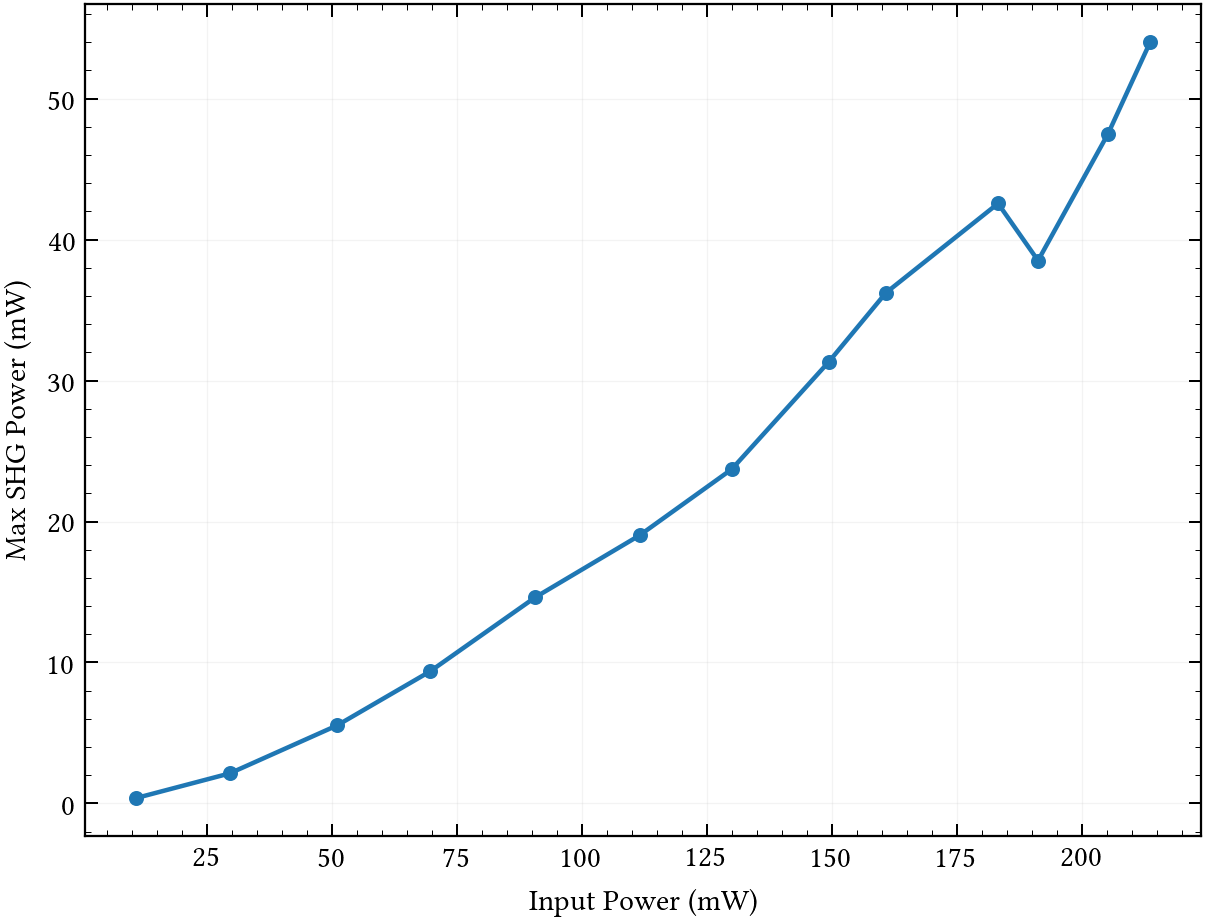

In [13]:
# Plot the max SHG power vs input power
plt.figure(figsize=(8, 6))
plt.plot(P_in, P_out_max, 'o-')
plt.xlabel('Input Power (mW)')
plt.ylabel('Max SHG Power (mW)')
# plt.title('Max SHG Power vs Input Power')
plt.grid()
plt.show()

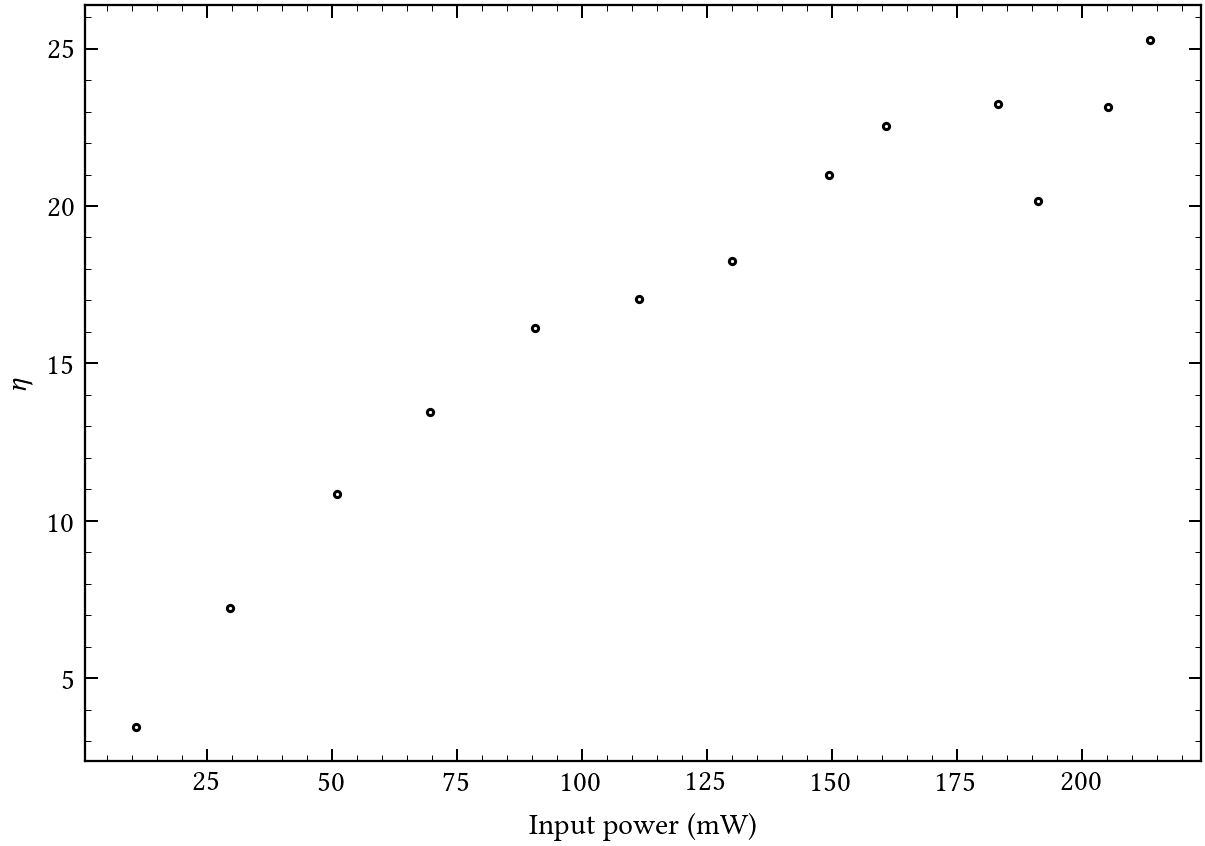

In [68]:
# Figure
fig, ax1 = plt.subplots(figsize=(7, 5))

eta = P_out_max / P_in * 100  # conversion to percentage

# -------------------------


# plt.plot(P_in, P_out, ".", color="black", markersize=5,
#          markerfacecolor="white", markeredgewidth=1.2, label="data points")
plt.plot(P_in, eta , ".", color="black", markersize=5,
         markerfacecolor="white", markeredgewidth=1.2, label="data points")
plt.xlabel("Input power (mW)")
# plt.ylabel("Output power (mW)")
plt.ylabel(r"$\eta$")
# plt.legend()
plt.tight_layout()
plt.show()

#### Eta model

We model the external SHG efficiency as:

$$
\eta(P_\omega^{in}) = \frac{P_{2\omega}}{P_\omega^{in}}
= \frac{\eta_0\, P_\omega^{in}}{1 + P_\omega^{in}/P_{sat}}
$$

which corresponds to:

$$
P_{2\omega} = \frac{\eta_0 (P_\omega^{in})^2}{1 + P_\omega^{in}/P_{sat}}
$$

#### Physical origin (bow-tie cavity SHG)

In a bow-tie cavity, second-harmonic generation scales as:

$$
P_{2\omega} \propto P_{cav}^2
$$

with intracavity power:

$$
P_{cav} = G(P_\omega^{in}) \, P_\omega^{in}
$$

At low power, the cavity buildup \(G\) is approximately constant, giving:

$$
P_{2\omega} \propto (P_\omega^{in})^2
$$


#### Why saturation appears

At higher input power, several effects reduce the effective cavity enhancement:

- pump depletion by SHG
- thermal lensing in the nonlinear crystal
- cavity detuning from photothermal effects
- reduced mode matching at high circulating power

These effects are modeled phenomenologically as:

$$
G(P_\omega^{in}) \sim \frac{1}{1 + P_\omega^{in}/P_{sat}}
$$

#### Final scaling

Substituting this into the SHG relation gives:

$$
P_{2\omega} = \frac{\eta_0 (P_\omega^{in})^2}{1 + P_\omega^{in}/P_{sat}}
$$

and therefore:

$$
\eta(P_\omega^{in}) = \frac{\eta_0 P_\omega^{in}}{1 + P_\omega^{in}/P_{sat}}
$$


#### Parameters

- **η₀**: low-power conversion efficiency slope (includes cavity buildup + nonlinear coupling)
- **P_sat**: effective saturation power where depletion and thermal effects become significant

In [31]:
def eta_model(P_in, eta0, P_sat):
    return (eta0 * P_in) / (1.0 + P_in / P_sat)

In [32]:
# efficiency as a fraction
eta_frac = P_out_max / P_in

# remove any zero-power points
mask = np.isfinite(eta_frac) & (P_in > 0)

popt, pcov = curve_fit(
    eta_model,
    P_in[mask],
    eta_frac[mask],
    p0=[eta_frac.max(), np.median(P_in)]
)

eta0, kappa = popt   # kappa = P_sat

print(f"eta0   = {eta0:.4f}")
print(f"kappa  = {kappa:.6f}")

# smooth curve for plotting
P_fit = np.linspace(0, P_in.max(), 500)

eta_fit = eta_model(P_fit, *popt)      # fraction
Pout_fit = P_fit * eta_fit             # mW

# Doubling efficiency (%)
eta = 100 * P_out_max / np.where(P_in == 0, np.nan, P_in)

eta_error = eta * np.sqrt(
    (P_out_error / P_out_max)**2 +
    (P_in_error / P_in)**2
)

eta0   = 0.0030
kappa  = 128.030527


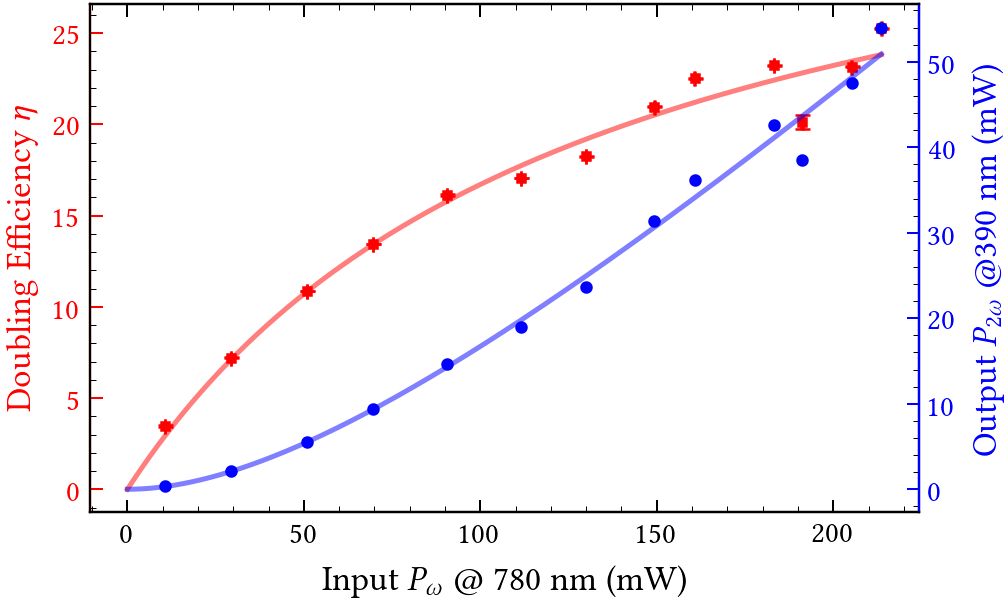

In [33]:
fig, ax1 = plt.subplots()

# -------------------------
# Left axis: efficiency
# -------------------------
# ax1.plot(
#     P_in, eta,
#     's', color='red',
#     markersize=5,
#     markerfacecolor='red',
#     label='Efficiency'
# )

ax1.errorbar(
    P_in,
    eta,
    xerr=P_in_error,
    yerr=eta_error,
    fmt='s',
    color='red',
    markersize=3,
    markerfacecolor='red',
    capsize=3,
    label='Efficiency'
)

ax1.plot(
    P_fit,
    100 * eta_fit,
    '-',
    color='red',
    alpha=0.5,
    lw=2
)

ax1.set_xlabel(r'Input $P_\omega$ @ 780 nm (mW)', fontsize=14)
ax1.set_ylabel(r'Doubling Efficiency $\eta$',
               color='red', fontsize=14)

ax1.tick_params(axis='y', colors='red')

# -------------------------
# Right axis: UV output power
# -------------------------
ax2 = ax1.twinx()

ax2.plot(
    P_in, P_out_max,
    '.',
    color='blue',
    markersize=5,
    markerfacecolor='white',
    markeredgewidth=2.5,
    label='UV power'
)

ax2.plot(
    P_fit,
    Pout_fit,
    '-',
    color='blue',
    alpha=0.5,
    lw=2
)

ax2.set_ylabel(r'Output $P_{2\omega}$ @390 nm (mW)',
               color='blue', fontsize=14)

ax2.tick_params(axis='y', colors='blue')


# Styling
ax1.spines['left'].set_color('red')
ax2.spines['right'].set_color('blue')

ax1.tick_params(labelsize=12)
ax2.tick_params(labelsize=12)

plt.tight_layout()
plt.show()

### Checking temperature drift

In [ ]:
def exp_decay(P, T_inf, A, P0):
    return T_inf + A * np.exp(-P / P0)

In [ ]:
p0 = [
    T_meas.min(),                    # T_inf
    T_meas.max() - T_meas.min(),     # A
    P_in.mean()                      # P0
]

popt, pcov = curve_fit(
    exp_decay,
    P_in,
    T_meas,
    sigma=T_meas_error,      # optional weighting
    absolute_sigma=True,
    p0=p0
)

T_inf, A, P0 = popt
dT_inf, dA, dP0 = np.sqrt(np.diag(pcov))

print(f"T_inf = {T_inf:.3f} ± {dT_inf:.3f}")
print(f"A     = {A:.3f} ± {dA:.3f}")
print(f"P0    = {P0:.3f} ± {dP0:.3f} mW")

T_inf = 42.318 ± 0.025
A     = 1.613 ± 0.022
P0    = 169.532 ± 4.971 mW


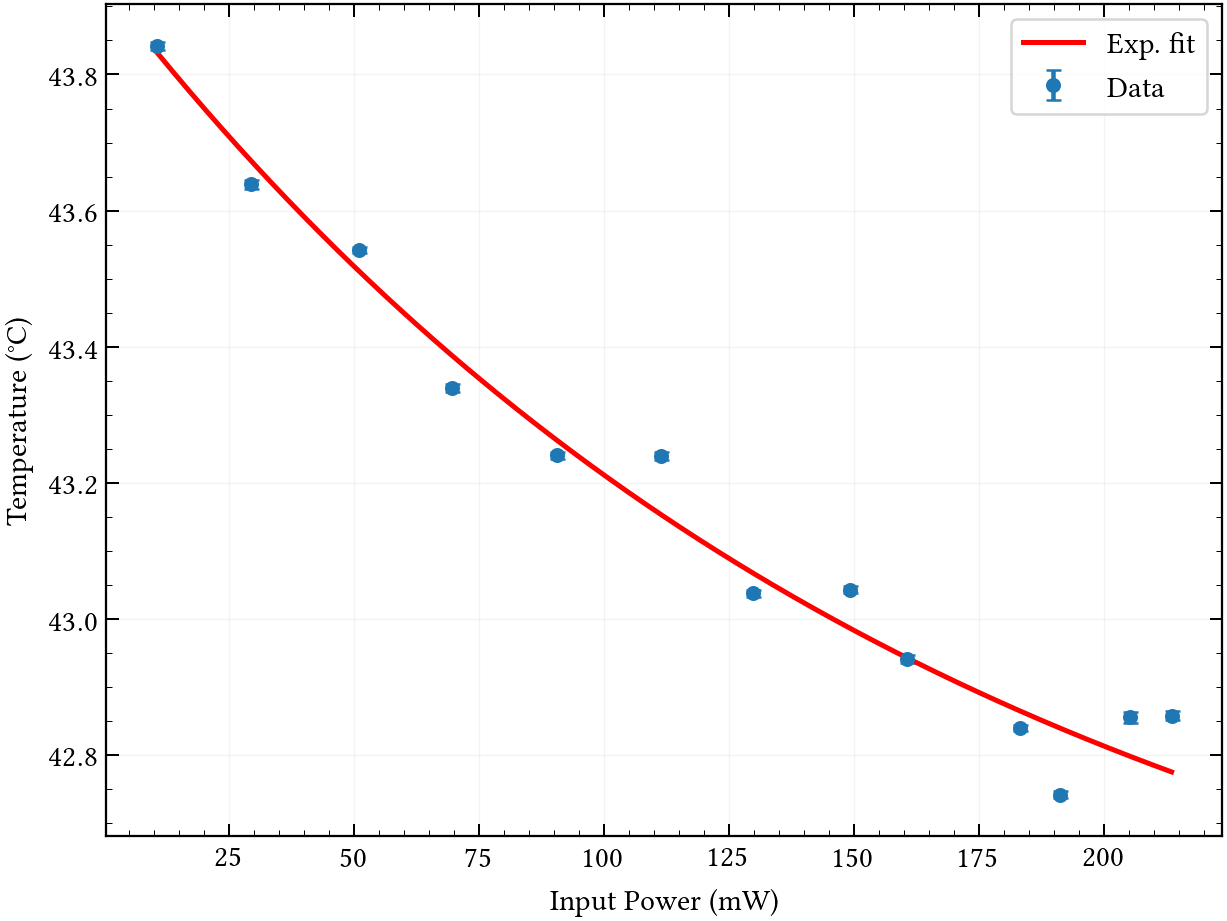

In [90]:
P_fit = np.linspace(P_in.min(), P_in.max(), 500)

plt.figure(figsize=(8,6))

plt.errorbar(
    P_in,
    T_meas,
    yerr=T_meas_error,
    fmt='o',
    capsize=3,
    label='Data'
)

plt.plot(
    P_fit,
    exp_decay(P_fit, *popt),
    'r-',
    lw=2,
    label='Exp. fit'
)

plt.xlabel('Input Power (mW)')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()

In [45]:
# Linear fit: T = a + b*P
coeffs_linear = np.polyfit(P_in, T_meas, 1)
T_fit_linear = np.polyval(coeffs_linear, P_in)

print(f"Linear coefficients: a = {coeffs_linear[1]:.3f}, b = {coeffs_linear[0]:.5f}")

Linear coefficients: a = 43.405, b = -0.00412


In [46]:
# Quadratic fit: T = a + b*P + c*P^2
coeffs_quad = np.polyfit(P_in, T_meas, 2)
T_fit_quad = np.polyval(coeffs_quad, P_in)

print(f"Quadratic coefficients: a = {coeffs_quad[2]:.3f}, b = {coeffs_quad[1]:.5f}, c = {coeffs_quad[0]:.7f}")

Quadratic coefficients: a = 43.376, b = -0.00323, c = -0.0000038


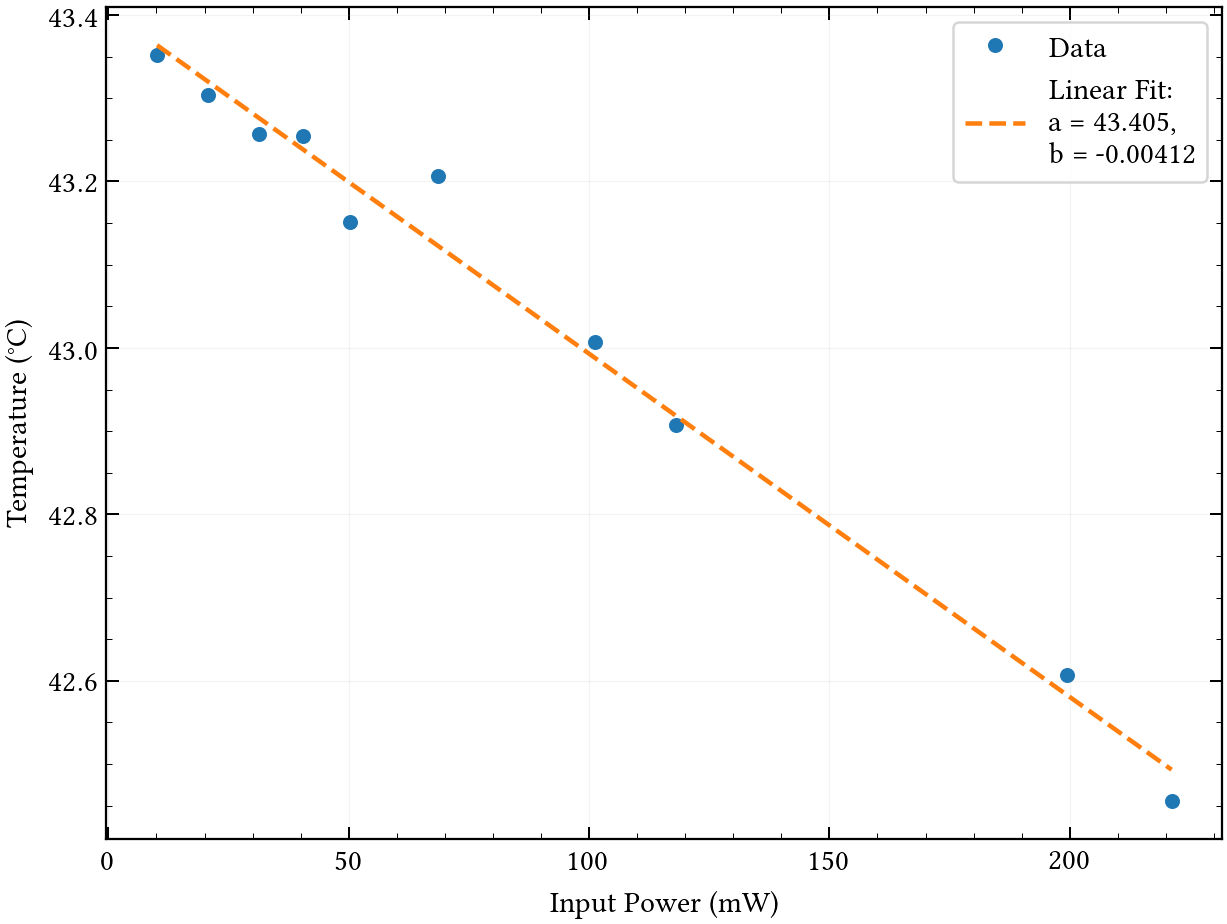

In [48]:
plt.figure(figsize=(8, 6))
plt.plot(P_in, T_meas, 'o', label='Data')
plt.plot(P_in, T_fit_linear, '--', label=f'Linear Fit:\na = {coeffs_linear[1]:.3f},\nb = {coeffs_linear[0]:.5f}')
# plt.plot(P_in, T_fit_quad, '-', label='Quadratic Fit')
# plt.plot(P_in, T_fit_exp, '-.', label='Exponential Fit')
plt.xlabel('Input Power (mW)')
plt.ylabel('Temperature (°C)')
plt.grid()
plt.legend()
plt.show()

In [44]:
# Extrapolate each fit to P = 0
P_zero = 0
T_linear_zero = np.polyval(coeffs_linear, P_zero)
T_quad_zero = np.polyval(coeffs_quad, P_zero)

print(f"Extrapolated T at P=0 mW:")
print(f"Linear: {T_linear_zero:.3f} °C")
print(f"Quadratic: {T_quad_zero:.3f} °C")

Extrapolated T at P=0 mW:
Linear: 43.405 °C
Quadratic: 43.376 °C


## Waist scan

In [12]:
# Manually define the waist corresponding to each focal length
# Forgot to add it before in the acquisition notebook, so I add it here for the plot
# Won't be necessary for the future, it is added in the acquisition notebook
waists = {
    500.0: 70.1,  # mm & µm
    400.0: 53.5,  # mm & µm
    200.0: 24.5   # mm & µm
}

In [13]:
path_folder_data = r"./data/data_temp_SHG/waist_scan 05 05"
folder_data_files = os.listdir(path_folder_data)
print(folder_data_files)

['temp.json', 'waist_scan']


In [14]:
# List all files in the folder
name_exp = 'waist_scan'
folder_data_files = os.listdir(path_folder_data + '/' + name_exp)
print(folder_data_files)

['2026_05_05__15_08_16__waist_scan.h5', '2026_05_05__15_10_23__waist_scan.h5', '2026_05_05__15_15_47__waist_scan.h5']


In [15]:

w_list = []
eta_list = []
eta_err_list = []

aqm = AcquisitionAnalysisManager( os.path.join(path_folder_data, name_exp))

for name in folder_data_files:
    full_path = os.path.join(path_folder_data, name_exp, name)
    aqm.analysis_cell(filename=full_path)

    Pin = float(aqm.data["Pin"])        # mW
    Pshg = float(aqm.data["mean_mW"])   # mW
    Perr = float(aqm.data["error_mW"])  # mW

    eta = Pshg / Pin # conversion efficiency
    eta_err = Perr / Pin

    f = float(aqm.data["focal_length_mm"])
    waist = waists.get(f, None)

    w_list.append(waist)
    eta_list.append(eta)
    eta_err_list.append(eta_err)

    # print(aqm.data)

INFO:2026_05_05__15_08_16__waist_scan


INFO:2026_05_05__15_10_23__waist_scan


INFO:2026_05_05__15_15_47__waist_scan


In [16]:
# Convert to arrays
w = np.array(w_list)
eta = np.array(eta_list)
eta_err = np.array(eta_err_list)

print("Waists (µm):", w)
print("Conversion efficiencies:", eta)

Waists (µm): [53.5 24.5 70.1]
Conversion efficiencies: [0.0006781  0.00140509 0.00060392]


In [17]:
# Fit the data to the model eta(w0) = A * w0^2 / (w0^4 + wc^4)
def eta_model(w0, A, wc):
    """
    For larger waists, the conversion efficiency decreases as 1/w0^2, while for smaller waists, it decreases as w0^2. The maximum efficiency occurs at w0 = wc, where eta(wc) = A/2.
    :param w0: beam waist (µm)
    :param A: maximum conversion efficiency (at w0 = wc)
    :param wc: optimal beam waist for maximum conversion efficiency (µm)

    :return: conversion efficiency eta
    """
    return A * w0**2 / (w0**4 + wc**4)

# Initial guess for fitting parameters
p0 = [np.max(eta), np.mean(w)]
popt, pcov = curve_fit(eta_model, w, eta, p0=p0, sigma=eta_err, absolute_sigma=True)
w_fit = np.linspace(10, 80, 200)
eta_fit_values = eta_model(w_fit, *popt)

In [18]:
L = 20e-3  # 20 mm in meters

# Boyd-Kleinman focusing function for perfect phase matching
def bk_h(xi):
    """
    Minimal Boyd-Kleinman focusing function for perfect phase matching.
    :param xi: xi = L / (2 z_R)
    """

    def integrand(t):
        return 1 / (1 + 1j*t)

    val, _ = quad(lambda t: np.real(integrand(t)), -xi, xi)
    vali, _ = quad(lambda t: np.imag(integrand(t)), -xi, xi)

    I = val + 1j * vali

    return np.abs(I)**2 / (4 * xi)


def eta_bk(w0_um, A, s):
    """
    Boyd-Kleinman model for SHG efficiency.
    :param w0_um: measured waist in um
    :param A: global efficiency scale
    :param s: waist calibration factor

    :return: conversion efficiency eta 
    """

    w0 = s * w0_um * 1e-6
    zR = np.pi * w0**2 / wavelength
    xi = L / (2 * zR)

    h = np.array([bk_h(x) for x in xi])

    return A * h

p0 = [np.max(eta), 1.0]

popt, pcov = curve_fit(
    eta_bk,
    w,
    eta,
    p0=p0,
    sigma=eta_err,
    absolute_sigma=True,
    bounds=([0, 0.3], [np.inf, 3.0]),
    maxfev=10000
)

A_fit, s_fit = popt

print(f"A = {A_fit:.4e}")
print(f"waist calibration factor s = {s_fit:.3f}")

w_fit = np.linspace(10, 90, 200)
eta_fit_values_bk = eta_bk(w_fit, *popt)

A = 2.2246e-03
waist calibration factor s = 1.517


Optimal waist from simple model: 30.9 µm
Optimal waist from Boyd-Kleinman model: 27.7 µm


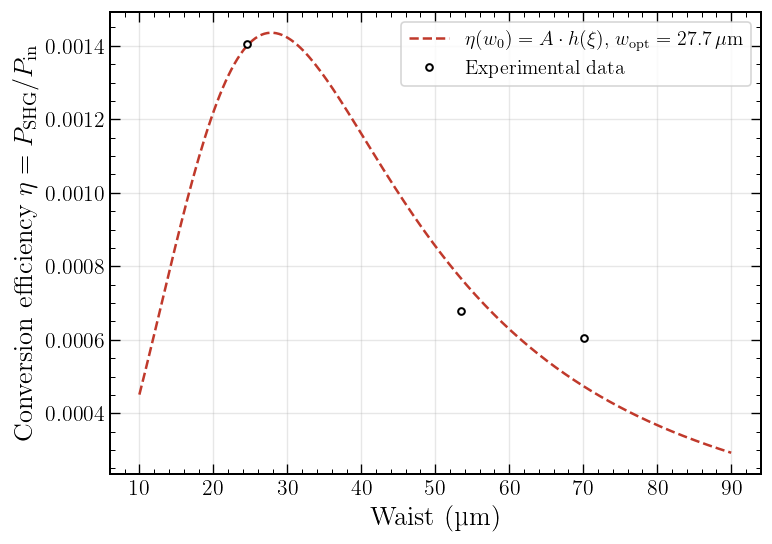

In [27]:
# Plot the coefficient eta vs waist
plt.figure(figsize=(7,5))

# Curve fits
w0_optimal = w_fit[np.argmax(eta_fit_values)]
w0_optimal_bk = w_fit[np.argmax(eta_fit_values_bk)]
print(f"Optimal waist from simple model: {w0_optimal:.1f} µm")
print(f"Optimal waist from Boyd-Kleinman model: {w0_optimal_bk:.1f} µm")
# plt.plot(w_fit[w0_optimal], eta_fit_values[w0_optimal], 'rx', label=f'$w_{{opt}}=${w_fit[w0_optimal]:.1f} µm')
# plt.plot(w_fit[w0_optimal_bk], eta_fit_values_bk[w0_optimal_bk], 'gx', label=f'$w_{{opt}}=${w_fit[w0_optimal_bk]:.1f} µm')
# plt.plot(
#     w_fit,
#     eta_fit_values,
#     'r--',
#     label=rf'$\eta(w_0)=\frac{{A w_0^2}}{{w_0^4+w_c^4}}$, '
#           rf'$w_{{\mathrm{{opt}}}}={w0_optimal:.1f}\,\mu\mathrm{{m}}$'
# )

plt.plot(
    w_fit,
    eta_fit_values_bk,
    color="#C0392B",
    linestyle="--",
    linewidth=1.5,
    label=rf'$\eta(w_0) = A \cdot h(\xi)$, '
          rf'$w_{{\mathrm{{opt}}}}={w0_optimal_bk:.1f}\,\mu\mathrm{{m}}$'
)

# plt.errorbar(
#     w, 
#     eta, 
#     yerr=eta_err, 
#     fmt='o', 
#     color="black",
#     markersize=4,
#     markerfacecolor="white",
#     markeredgewidth=1.2,
#     capsize=3, 
#     label='Experimental data'
# )

plt.plot(
    w, 
    eta, 
    'o',
    color="black",
    markersize=4,
    markerfacecolor="white",
    markeredgewidth=1.2,
    label='Experimental data'
)

plt.xlabel("Waist (µm)")
plt.ylabel(r"Conversion efficiency $\eta = P_{\mathrm{SHG}} / P_{\mathrm{in}}$")
# plt.title("SHG efficiency vs waist")
plt.legend(loc='upper right')

plt.grid(alpha=0.3)
# plt.tight_layout()
plt.show()

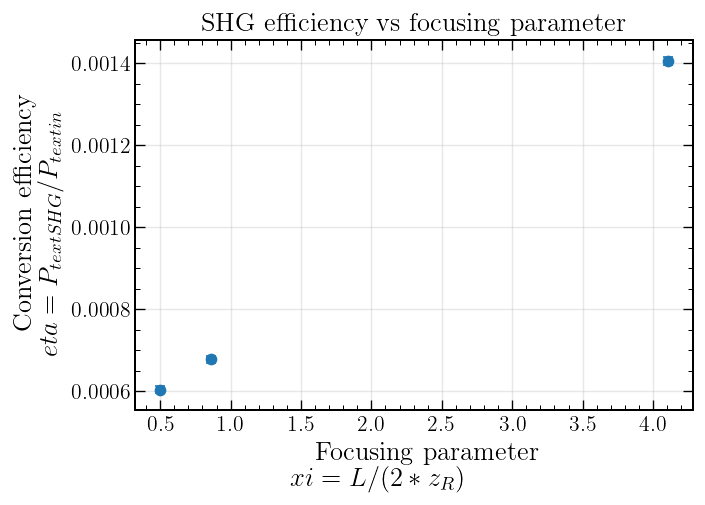

In [23]:
# Plot efficiency eta vs focusing parameter xi = L / (2 * z_R)
L = 20.0  # mm
z_R = np.pi * w**2 / (780-6)  # Rayleigh range in mm
xi = L / (2 * z_R)
plt.figure()
plt.errorbar(xi, eta, yerr=eta_err, fmt='o', capsize=3)
plt.xlabel(r"Focusing parameter $\\xi = L / (2 * z_R)$")
plt.ylabel(r"Conversion efficiency $\\eta = P_{\\text{SHG}} / P_{\\text{in}}$")
plt.title("SHG efficiency vs focusing parameter")
plt.grid()
plt.show()